<a href="https://colab.research.google.com/github/Janmeshree/ML-PRACS/blob/main/ML_LINEAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [33]:
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset Shape: (20640, 10)

Dataset Info:
<class 'pandas.cor

In [34]:
sample_df = df.sample(n=100, random_state=42)

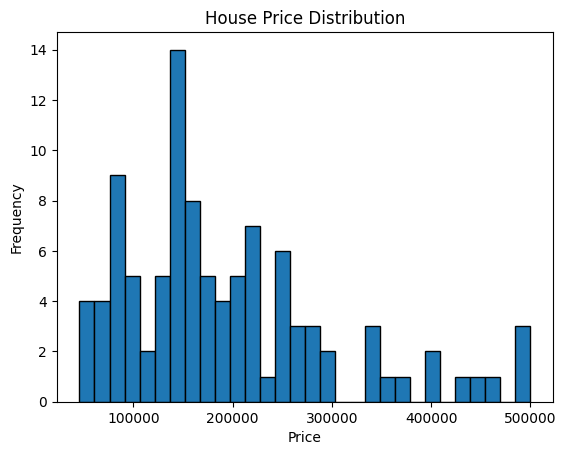

In [35]:
plt.hist(sample_df["median_house_value"], bins=30, edgecolor="black")
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

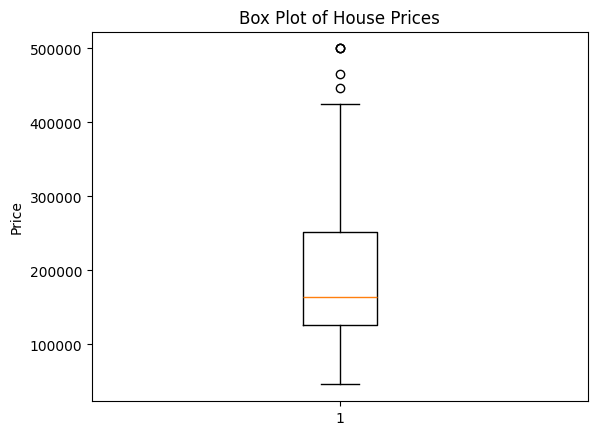

In [36]:
plt.boxplot(sample_df["median_house_value"])
plt.title("Box Plot of House Prices")
plt.ylabel("Price")
plt.show()

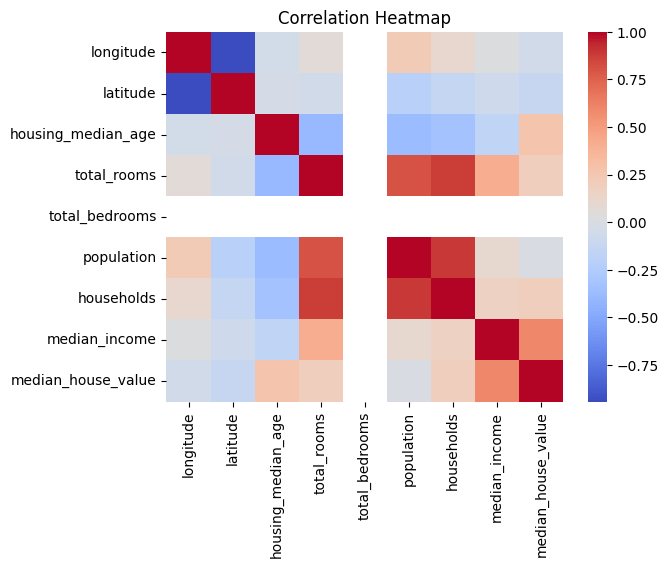

In [38]:
import seaborn as sns

sns.heatmap(sample_df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [39]:
print("Missing values in dataset:\n")
print(sample_df.isnull().sum())

Missing values in dataset:

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        100
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [40]:
sample_df["total_bedrooms"].fillna(sample_df["total_bedrooms"].mean(), inplace=True)

/tmp/ipykernel_2823/681676079.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_df["total_bedrooms"].fillna(sample_df["total_bedrooms"].mean(), inplace=True)


In [41]:
X = sample_df[["median_income"]]
y = sample_df["median_house_value"]

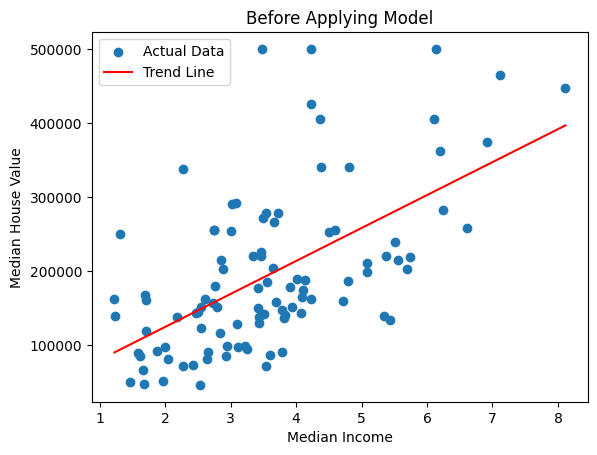

In [42]:
# scatter plot (before model)
plt.scatter(X, y, label="Actual Data")

# simple line using numpy (not model yet)
z = np.polyfit(X["median_income"], y, 1)
p = np.poly1d(z)

# sort for clean line
X_sorted = np.sort(X["median_income"])
plt.plot(X_sorted, p(X_sorted), color="red", label="Trend Line")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Before Applying Model")

plt.legend()
plt.show()

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test)

In [47]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.2923576069695605
Testing Accuracy: 0.5250290088338518


In [48]:
if train_score > test_score + 0.1:
    print("Model may be OVERFITTING")
elif test_score > train_score:
    print("Model may be UNDERFITTING")
else:
    print("Model seems to be WELL FIT")

Model may be UNDERFITTING


In [49]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 5451128975.020885


In [50]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 73831.76128889846


In [51]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.5250290088338518


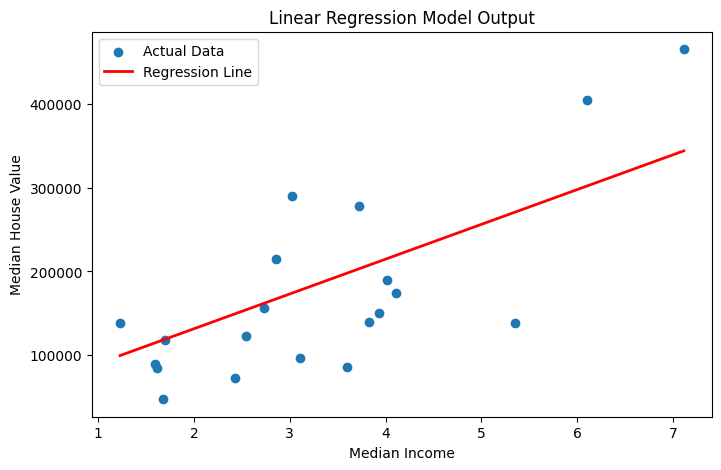

In [57]:
# take same 100 sample (if not already taken)
sample_df = df.sample(n=100, random_state=42)

X = sample_df[["median_income"]]
y = sample_df["median_house_value"]

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# plot final graph
plt.figure(figsize=(8,5))

# actual points
plt.scatter(X_test, y_test, label="Actual Data")

# sort for straight line
sorted_indices = X_test["median_income"].argsort()
X_sorted = X_test.iloc[sorted_indices]
y_sorted = y_pred[sorted_indices]

# regression line
plt.plot(X_sorted, y_sorted, color="red", linewidth=2, label="Regression Line")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression Model Output")

plt.legend()
plt.show()

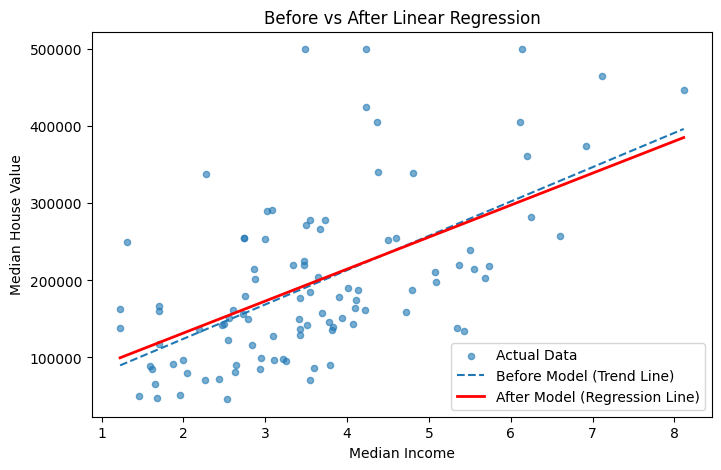

In [56]:
# predictions on full dataset
y_all_pred = model.predict(X)

plt.figure(figsize=(8,5))

# Actual data
plt.scatter(X, y, s=20, alpha=0.6, label="Actual Data")

# BEFORE MODEL (trend line using numpy)
z = np.polyfit(X["median_income"], y, 1)
p = np.poly1d(z)

X_sorted = np.sort(X["median_income"])
plt.plot(X_sorted, p(X_sorted), linestyle="dashed", label="Before Model (Trend Line)")

# AFTER MODEL (trained regression line)
sorted_indices = X["median_income"].argsort()
X_sorted2 = X.iloc[sorted_indices]
y_sorted2 = y_all_pred[sorted_indices]

plt.plot(X_sorted2, y_sorted2, color="red", linewidth=2, label="After Model (Regression Line)")

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Before vs After Linear Regression")

plt.legend()
plt.show()